### Dataset loader for the deep learning model training.

In [1]:
import time
import torch
import random
import numpy as np 
from glob import glob
from pyrsimg import imsShow 
from notebooks import config
from utils.utils import read_scenes
from torchvision.transforms import v2
from utils.data_loader import GaussianNoise
from utils.data_loader import SceneArraySet, PatchPathSet


In [2]:
patch_size = 512  ## patch size setting
### traset
paths_scene_tra, paths_truth_tra = config.paths_scene_tra, config.paths_truth_tra
print(f'train scenes: {len(paths_scene_tra)}')
### valset
paths_valset = sorted(glob(f'data/dset/valset/patch_{patch_size}/*'))  ## for model prediction 
# paths_patch_valset = sorted(glob(f'data/dset/valset/patch_{patch_size}_dem_adjust/*'))
print(f'vali patch: {len(paths_valset)}')


train scenes: 172
vali patch: 217


In [3]:
scenes_arr, truths_arr = read_scenes(paths_scene_tra, paths_truth_tra)    

In [ ]:
scene_truth_ls =  list(zip(scenes_arr, truths_arr))
scene_truth_ls = [np.concatenate([scene, truth[:, :, np.newaxis]], axis=-1) 
                            for scene, truth in scene_truth_ls]

In [175]:
transforms_tra = v2.Compose([
      v2.ToImage(),
      v2.RandomCrop(size=(patch_size, patch_size), padding = 50, fill=0),
      v2.RandomApply([v2.RandomRotation(degrees=15)], p=0.5),
      v2.RandomHorizontalFlip(p=0.5),
      v2.RandomVerticalFlip(p=0.5),
      GaussianNoise(mean = 0, sigma_max=0.1, p=0.3)    
       ])
transforms_val = v2.Compose([
      v2.ToDtype(torch.float32),
       ])

In [162]:
tra_dset = SceneArraySet(scene_truth_list = scene_truth_ls, 
                          transforms = transforms_tra)
val_dset = PatchPathSet(paths_valset=paths_valset, 
                          transforms=transforms_val)
print(len(tra_dset), len(val_dset))


172 217


torch.Size([6, 512, 512]) torch.Size([1, 512, 512])


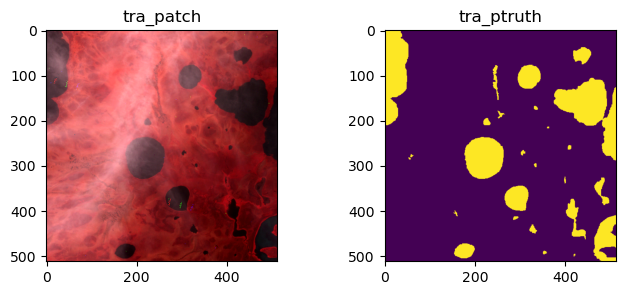

In [174]:
patch, ptruth = tra_dset[0]
print(patch.shape, ptruth.shape)
imsShow([patch.numpy().astype(float).transpose((1, 2, 0)), ptruth.numpy()], 
              clip_list=[2,2], 
              img_name_list=['tra_patch','tra_ptruth'], 
              color_bands_list=[(3,2,1),{0,0,0}],
              figsize=(8, 3));


training data size: 172
validation data size: 217


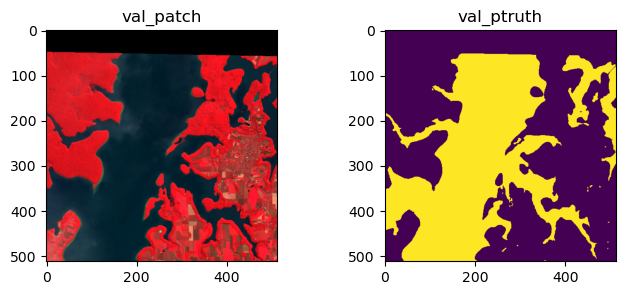

In [121]:
id = random.randint(0, len(val_dset)-1)
patch, ptruth = val_dset[id]
print('training data size:',len(tra_dset))
print('validation data size:', len(val_dset))
imsShow([patch.numpy().transpose(1,2,0), 
                ptruth.numpy().transpose(1,2,0)], 
          clip_list=[2,0], 
          img_name_list=['val_patch','val_ptruth'], 
          color_bands_list=[(3,2,1),{0,0,0}],
          figsize=(8, 3));


In [122]:
### Create DataLoader
tra_loader = torch.utils.data.DataLoader(tra_dset, 
                                         batch_size=4, 
                                         shuffle=True, 
                                         num_workers=5)
val_loader = torch.utils.data.DataLoader(val_dset, 
                                         batch_size=4,
                                         num_workers=5)


In [124]:
# ## check data loading time
# time_start = time.time()
# for x_batch, y_batch in tra_loader:
#   print(f"traBatch processing time: {time.time() - time_start:.1f}")
# time_start = time.time()  
# check data loading time
time_start = time.time()
for x_batch, y_batch in val_loader:
  print(f"valBatch processing time: {time.time() - time_start:.1f}")
time_start = time.time()   


valBatch processing time: 0.3
valBatch processing time: 0.3
valBatch processing time: 0.3
valBatch processing time: 0.3
valBatch processing time: 0.3
valBatch processing time: 0.4
valBatch processing time: 0.4
valBatch processing time: 0.4
valBatch processing time: 0.4
valBatch processing time: 0.4
valBatch processing time: 0.5
valBatch processing time: 0.5
valBatch processing time: 0.5
valBatch processing time: 0.5
valBatch processing time: 0.5
valBatch processing time: 0.6
valBatch processing time: 0.6
valBatch processing time: 0.6
valBatch processing time: 0.6
valBatch processing time: 0.6
valBatch processing time: 0.7
valBatch processing time: 0.7
valBatch processing time: 0.7
valBatch processing time: 0.7
valBatch processing time: 0.7
valBatch processing time: 0.8
valBatch processing time: 0.8
valBatch processing time: 0.9
valBatch processing time: 0.9
valBatch processing time: 0.9
valBatch processing time: 1.0
valBatch processing time: 1.0
valBatch processing time: 1.0
valBatch p

torch.Size([4, 6, 512, 512]) torch.Size([4, 1, 512, 512])


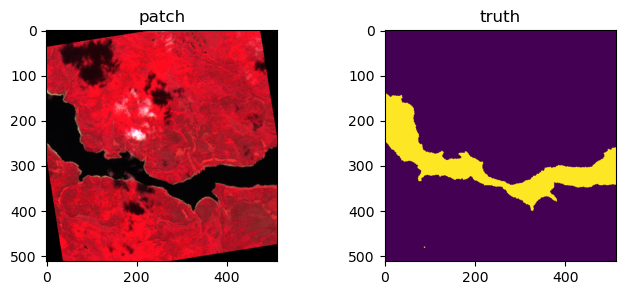

In [125]:
# for patch, truth in tra_loader:
#     print(patch.shape)
batch_patch, batch_truth = next(iter(tra_loader))
print(batch_patch.shape, batch_truth.shape)
patch_arr = batch_patch[0].numpy().transpose((1, 2, 0))
truth_arr = batch_truth[0].numpy().squeeze()
imsShow([patch_arr, truth_arr],  
          color_bands_list=[[3,2,1], None],
          img_name_list=['patch', 'truth'], 
          clip_list=[2, 2], 
          figsize=(8, 3));
